# A/B Testing Product analysis

In [4]:
import pandas as pd
import numpy as np 

In [1]:
import PIL

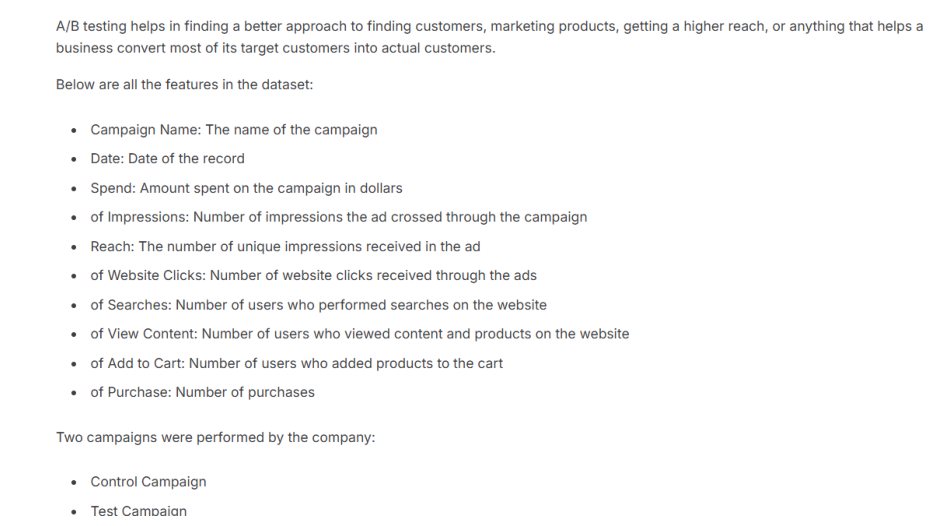

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
# Open image
img = Image.open(r"C:\Users\nixty\OneDrive\Pictures\Screenshots\Screenshot 2026-05-12 110205.png")

# Plot image
plt.imshow(img)
plt.axis("off")
plt.show()

### Control group & Test group data formatting 

### Control Group

In [ ]:
with open("control_group.csv", "r") as file:
    content = file.read()

content = content.replace(";", ",")

In [ ]:
with open("control_group.csv", "w") as file:
    file.write(content)

### Test Group

In [15]:
with open("test_group.csv", "r") as file:
    content = file.read()

content = content.replace(";", ",")

In [16]:
with open("test_group.csv", "w") as file:
    file.write(content)

## Control Group Df

In [8]:
control_df = pd.read_csv('control_group.csv')

In [9]:
control_df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
control_df.rename(columns = {"# of Impressions" : "No. of Impressions", "# of Website Clicks": "No. of Website Clicks",
                             "# of Searches" : "No. of Searches",	"# of View Content" : "No. of View Content",
                             "# of Add to Cart" : "No. of Add to Cart",
                             "# of Purchase" : "No. of Purchase"}, inplace = True)

In [11]:
control_df.shape

(30, 10)

In [12]:
control_df.isnull().sum()

Campaign Name            0
Date                     0
Spend [USD]              0
No. of Impressions       1
Reach                    1
No. of Website Clicks    1
No. of Searches          1
No. of View Content      1
No. of Add to Cart       1
No. of Purchase          1
dtype: int64

## Date conversion 

In [13]:
import pandas as pd

date_string = control_df['Date']

date_obj = pd.to_datetime(
    date_string,
    format="%d.%m.%Y"
)

control_df['Day'] = date_obj.dt.day

## Replace null values in control group with the mean data

In [14]:
control_df["No. of Impressions"] = control_df["No. of Impressions"].fillna(value=int(control_df["No. of Impressions"].mean()))
control_df["Reach"] = control_df["Reach"].fillna(value=int(control_df["Reach"].mean()))
control_df["No. of Website Clicks"] = control_df["No. of Website Clicks"].fillna(value=int(control_df["No. of Website Clicks"].mean()))
control_df["No. of Searches"] = control_df["No. of Searches"].fillna(value=int(control_df["No. of Searches"].mean()))
control_df["No. of View Content"] = control_df["No. of View Content"].fillna(value=int(control_df["No. of View Content"].mean()))
control_df["No. of Add to Cart"] = control_df["No. of Add to Cart"].fillna(value=int(control_df["No. of Add to Cart"].mean()))
control_df["No. of Purchase"] = control_df["No. of Purchase"].fillna(value=int(control_df["No. of Purchase"].mean()))

## Test Group Df

In [15]:
test_df = pd.read_csv('test_group.csv')

In [16]:
test_df.tail()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
25,Test Campaign,26.08.2019,2311,80841,61589,3820,2037,1046,346,284
26,Test Campaign,27.08.2019,2915,111469,92159,6435,2976,2552,992,771
27,Test Campaign,28.08.2019,2247,54627,41267,8144,2432,1281,1009,721
28,Test Campaign,29.08.2019,2805,67444,43219,7651,1920,1240,1168,677
29,Test Campaign,30.08.2019,1977,120203,89380,4399,2978,1625,1034,572


In [17]:
test_df.rename(columns = {"# of Impressions" : "No. of Impressions", "# of Website Clicks": "No. of Website Clicks",
                             "# of Searches" : "No. of Searches",	"# of View Content" : "No. of View Content",
                             "# of Add to Cart" : "No. of Add to Cart",
                             "# of Purchase" : "No. of Purchase"}, inplace = True)

In [18]:
test_df.isnull().sum() # No null values in test group data

Campaign Name            0
Date                     0
Spend [USD]              0
No. of Impressions       0
Reach                    0
No. of Website Clicks    0
No. of Searches          0
No. of View Content      0
No. of Add to Cart       0
No. of Purchase          0
dtype: int64

## Date Conversion

In [19]:
import pandas as pd

date_string = test_df['Date']

date_obj = pd.to_datetime(
    date_string,
    format="%d.%m.%Y"
)

test_df['Day'] = date_obj.dt.day

# Combine both the control & test group

In [20]:
final_df = pd.concat([control_df, test_df]).sort_values(['Day','Campaign Name'])

### Total money spent on each campaign

In [21]:
spend_series = final_df.groupby('Campaign Name')['Spend [USD]'].sum()
website_click_series = final_df.groupby('Campaign Name')['No. of Website Clicks'].sum()
search_series = final_df.groupby('Campaign Name')['No. of Searches'].sum()
purchase_series = final_df.groupby('Campaign Name')['No. of Purchase'].sum()
add_to_cart_series = final_df.groupby('Campaign Name')['No. of Add to Cart'].sum()

### Total clicks, searches & purchases 

In [22]:
print('Control Clicks: ', final_df.groupby('Campaign Name')['No. of Website Clicks'].sum().iloc[0],'\n', 'Test Clicks: ', final_df.groupby('Campaign Name')['No. of Website Clicks'].sum().iloc[1])
print('\n', end ='')
print('Control Searches: ', final_df.groupby('Campaign Name')['No. of Searches'].sum().iloc[0],'\n', 'Test Searches: ', final_df.groupby('Campaign Name')['No. of Searches'].sum().iloc[1])
print('\n', end ='')
print('Control Purchases: ', final_df.groupby('Campaign Name')['No. of Purchase'].sum().iloc[0],'\n', 'Test Purchases: ', final_df.groupby('Campaign Name')['No. of Purchase'].sum().iloc[1])

Control Clicks:  159623.0 
 Test Clicks:  180970.0

Control Searches:  66639.0 
 Test Searches:  72569.0

Control Purchases:  15683.0 
 Test Purchases:  15637.0


### Average clicks, searches & purchases 

In [23]:
print('Control Clicks: ', final_df.groupby('Campaign Name')['No. of Website Clicks'].mean().iloc[0],'\n', 'Test Clicks: ', final_df.groupby('Campaign Name')['No. of Website Clicks'].mean().iloc[1])
print('\n', end ='')
print('Control Searches: ', final_df.groupby('Campaign Name')['No. of Searches'].mean().iloc[0],'\n', 'Test Searches: ', final_df.groupby('Campaign Name')['No. of Searches'].mean().iloc[1])
print('\n', end ='')
print('Control Purchases: ', final_df.groupby('Campaign Name')['No. of Purchase'].mean().iloc[0],'\n', 'Test Purchases: ', final_df.groupby('Campaign Name')['No. of Purchase'].mean().iloc[1])

Control Clicks:  5320.766666666666 
 Test Clicks:  6032.333333333333

Control Searches:  2221.3 
 Test Searches:  2418.9666666666667

Control Purchases:  522.7666666666667 
 Test Purchases:  521.2333333333333


### Total purchases are effectively equal.
15,683 (Control) vs. 15,637 (Test) — statistically significant difference in rate (p < 0.001) but the absolute gap is only 46 purchases, which is operationally negligible. Test achieved this parity only by spending more.

## Cost Efficiency

### Cost per Click

In [24]:
print('Cost per click for Control Campaign: ', spend_series['Control Campaign']/website_click_series['Control Campaign'])
print('Cost per click for Test Campaign: ', spend_series['Test Campaign']/website_click_series['Test Campaign'])

Cost per click for Control Campaign:  0.4300946605439066
Cost per click for Test Campaign:  0.42488810300049734


### Cost per Search

In [25]:
print('Cost per search for Control Campaign: ', spend_series['Control Campaign']/search_series['Control Campaign'])
print('Cost per search for Test Campaign: ', spend_series['Test Campaign']/search_series['Test Campaign'])

Cost per search for Control Campaign:  1.0302225423550773
Cost per search for Test Campaign:  1.0595708911518693


### Cost per Purchase

In [26]:
print('Cost per purchase for Control Campaign: ', spend_series['Control Campaign']/purchase_series['Control Campaign'])
print('Cost per purchase for Test Campaign: ', spend_series['Test Campaign']/purchase_series['Test Campaign'])

Cost per purchase for Control Campaign:  4.377542562009819
Cost per purchase for Test Campaign:  4.917311504764341


### Cost per add to cart event

In [27]:
print('Cost per add to carts for Control Campaign: ', spend_series['Control Campaign']/add_to_cart_series['Control Campaign'])
print('Cost per add to carts for Test Campaign: ', spend_series['Test Campaign']/add_to_cart_series['Test Campaign'])

Cost per add to carts for Control Campaign:  1.7603333333333333
Cost per add to carts for Test Campaign:  2.9075096422899493


### Cost efficiency favors Control.
Control's cost per purchase (USD 4.38) is 11 % lower than Test (USD 4.92). Cost per add-to-cart gap is even starker: USD 1.76 vs. USD 2.91 — Test spends 65% more per cart addition. While the cost-per-purchase difference is not statistically significant (p = 0.165), the directional consistency across CPC, cost-per-search, and cost-per-cart all point the same way.

## Funnel Analysis

In [30]:
import seaborn as sns

# Separate campaigns
control = final_df[final_df['Campaign Name'] == 'Control Campaign'].copy()
test = final_df[final_df['Campaign Name'] == 'Test Campaign'].copy()

# Aggregate totals
funnel_cols = final_df.columns[3:-1]

control_totals = control[funnel_cols].sum()
test_totals = test[funnel_cols].sum()

In [31]:
stages = ['Impressions', 'Reach', 'Clicks', 'Searches', 'View Content', 'Add to Cart', 'Purchase']

def get_stage_conversions(totals):
    values = totals.values
    # Each stage as % of the PREVIOUS stage (not impressions)
    rates = [100.0]  # Impressions is the baseline
    for i in range(1, len(values)):
        rate = (values[i] / values[i-1]) * 100 if values[i-1] > 0 else 0
        rates.append(round(rate, 2))
    return rates

control_rates = get_stage_conversions(control_totals)
test_rates = get_stage_conversions(test_totals)

funnel_df = pd.DataFrame({
    'Stage': stages,
    'Control': control_rates,
    'Test': test_rates
})

print(funnel_df)

          Stage  Control    Test
0   Impressions   100.00  100.00
1         Reach    81.09   71.72
2        Clicks     5.99   11.28
3      Searches    41.75   40.10
4  View Content    87.51   76.81
5   Add to Cart    66.88   47.45
6      Purchase    40.21   59.13


## User volume per event 

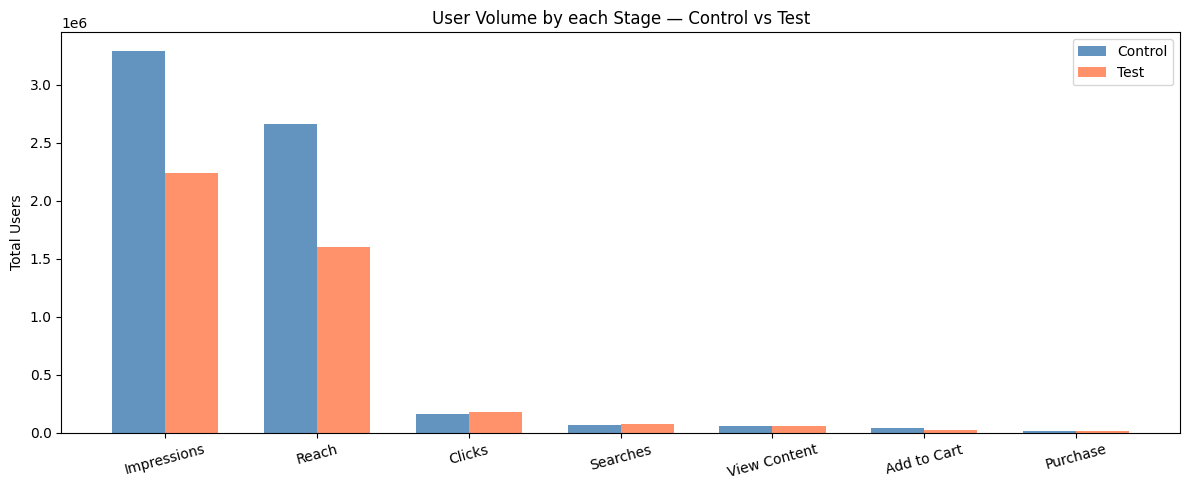

In [34]:
x = np.arange(len(stages))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, control_totals.values, width, label='Control', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, test_totals.values, width, label='Test', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(stages, rotation=15)
ax.set_ylabel('Total Users')
ax.set_title('User Volume by each Stage — Control vs Test')
ax.legend()
plt.tight_layout()
plt.show()

### Funnel test dataframe saved for Tableau visualization

In [33]:
funnel_df.to_csv('funnel test results.csv', index = False)

## Statistical Test

In [128]:
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import pandas as pd

# ── Two-proportion Z-test with CI and effect size ──────────────────────────
def two_prop_ztest(success_a, n_a, success_b, n_b, label):
    """
    success_a/b : number of successes (e.g. purchases)
    n_a/b       : total trials (e.g. total impressions)
    """
    p_a = success_a / n_a
    p_b = success_b / n_b

    # Z-test
    count = np.array([success_a, success_b])
    nobs  = np.array([n_a, n_b])
    z_stat, p_val = proportions_ztest(count, nobs)

    # 95% Confidence Interval on the difference (p_b - p_a)
    se = np.sqrt((p_a * (1 - p_a) / n_a) + (p_b * (1 - p_b) / n_b))
    diff = p_b - p_a
    ci_low  = diff - 1.96 * se
    ci_high = diff + 1.96 * se

    # Effect size — Cohen's h (standard for proportions)
    cohens_h = 2 * (np.arcsin(np.sqrt(p_b)) - np.arcsin(np.sqrt(p_a)))

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Control rate : {p_a:.4f}  ({success_a:,} / {n_a:,})")
    print(f"  Test rate    : {p_b:.4f}  ({success_b:,} / {n_b:,})")
    print(f"  Difference   : {diff:+.4f} ({diff*100:+.2f} pp)")
    print(f"  Z-statistic  : {z_stat:.4f}")
    print(f"  P-value      : {p_val:.4f}  {'Significant' if p_val < 0.05 else ' Not significant'}")
    print(f"  95% CI       : [{ci_low:+.4f}, {ci_high:+.4f}]")
    print(f"  Cohen's h    : {cohens_h:.4f}  ({interpret_cohens_h(cohens_h)})")

    return {
        'metric': label, 'control_rate': p_a, 'test_rate': p_b,
        'difference': diff, 'p_value': p_val,
        'ci_low': ci_low, 'ci_high': ci_high, 'cohens_h': cohens_h
    }


# ── Two-sample t-test with CI and effect size ──────────────────────────────
def two_sample_ttest(series_a, series_b, label):
    """
    series_a/b : pandas Series of daily values (e.g. daily spend-per-purchase)
    """
    # Drop NaN (days with 0 purchases → infinite CPP)
    a = series_a.dropna().replace([np.inf, -np.inf], np.nan).dropna()
    b = series_b.dropna().replace([np.inf, -np.inf], np.nan).dropna()

    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)  # Welch's t-test

    # 95% CI on the difference in means
    mean_diff = b.mean() - a.mean()
    se = np.sqrt((a.std()**2 / len(a)) + (b.std()**2 / len(b)))
    ci_low  = mean_diff - 1.96 * se
    ci_high = mean_diff + 1.96 * se

    # Effect size — Cohen's d
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Control mean : ${a.mean():.2f}  (n={len(a)} days)")
    print(f"  Test mean    : ${b.mean():.2f}  (n={len(b)} days)")
    print(f"  Difference   : ${mean_diff:+.2f}")
    print(f"  T-statistic  : {t_stat:.4f}")
    print(f"  P-value      : {p_val:.4f}  {'p value is significant' if p_val < 0.05 else 'p value is insignificant'}")
    print(f"  95% CI       : [${ci_low:+.2f}, ${ci_high:+.2f}]")
    print(f"  Cohen's d    : {cohens_d:.4f}  ({interpret_cohens_d(cohens_d)})")

    return {
        'metric': label, 'control_mean': a.mean(), 'test_mean': b.mean(),
        'difference': mean_diff, 'p_value': p_val,
        'ci_low': ci_low, 'ci_high': ci_high, 'cohens_d': cohens_d
    }


# ── Effect size interpreters ───────────────────────────────────────────────
def interpret_cohens_h(h):
    h = abs(h)
    if h < 0.2:   return "negligible effect"
    elif h < 0.5: return "small effect"
    elif h < 0.8: return "medium effect"
    else:         return "large effect"

def interpret_cohens_d(d):
    d = abs(d)
    if d < 0.2:   return "negligible effect"
    elif d < 0.5: return "small effect"
    elif d < 0.8: return "medium effect"
    else:         return "large effect"

In [ ]:
# Aggregate totals for proportion tests 

c = final_df[final_df['Campaign Name'] == 'Control Campaign']
t = final_df[final_df['Campaign Name'] == 'Test Campaign']

results = []

# Purchase Rate  (Purchases / Impressions)
results.append(two_prop_ztest(
    success_a = c['No. of Purchase'].sum(),
    n_a       = c['No. of Impressions'].sum(),
    success_b = t['No. of Purchase'].sum(),
    n_b       = t['No. of Impressions'].sum(),
    label     = "Purchase Rate (Purchases / Impressions)"
))

# 2. Click-Through Rate  (Clicks / Impressions)
results.append(two_prop_ztest(
    success_a = c['No. of Website Clicks'].sum(),
    n_a       = c['No. of Impressions'].sum(),
    success_b = t['No. of Website Clicks'].sum(),
    n_b       = t['No. of Impressions'].sum(),
    label     = "Click-Through Rate (Clicks / Impressions)"
))

# 3. Add-to-Cart Rate  (Add to Cart / Clicks)
results.append(two_prop_ztest(
    success_a = c['No. of Add to Cart'].sum(),
    n_a       = c['No. of Website Clicks'].sum(),
    success_b = t['No. of Add to Cart'].sum(),
    n_b       = t['No. of Website Clicks'].sum(),
    label     = "Add-to-Cart Rate (Cart / Clicks)"
))

# 4. Cost Per Purchase — daily level t-test
c_cpp = (c['Spend [USD]'] / c['No. of Purchase']).replace([np.inf], np.nan)
t_cpp = (t['Spend [USD]'] / t['No. of Purchase']).replace([np.inf], np.nan)

results.append(two_sample_ttest(
    series_a = c_cpp,
    series_b = t_cpp,
    label    = "Cost Per Purchase (Spend / Purchases)"
))

## Visualization


                                    metric  p_value  ci_low  ci_high significant
  Purchase Rate (Purchases / Impressions)   0.0000  0.0021   0.0023           ✅
Click-Through Rate (Clicks / Impressions)   0.0000  0.0319   0.0327           ✅
         Add-to-Cart Rate (Cart / Clicks)   0.0000 -0.1009  -0.0955           ✅
    Cost Per Purchase (Spend / Purchases)   0.1654 -0.3538   2.1512           ❌


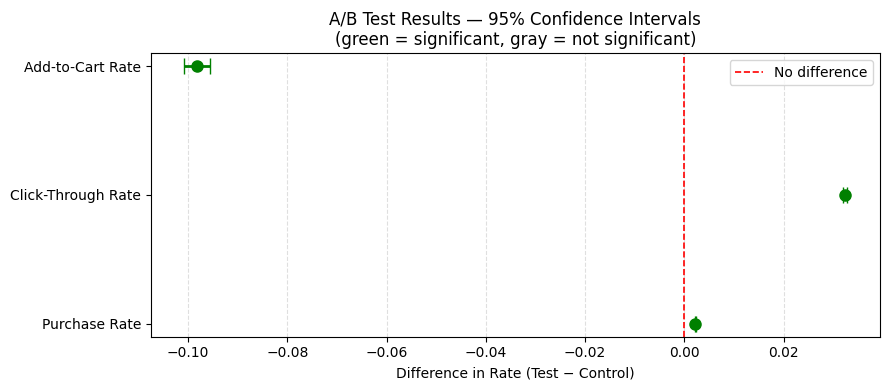

In [130]:
# ── Clean summary table ───────────────────────────────────────────────────
summary = pd.DataFrame(results)[['metric', 'p_value', 'ci_low', 'ci_high']]
summary['significant'] = summary['p_value'].apply(lambda x: '✅' if x < 0.05 else '❌')
summary['p_value'] = summary['p_value'].round(4)
summary['ci_low']  = summary['ci_low'].round(4)
summary['ci_high'] = summary['ci_high'].round(4)
print("\n", summary.to_string(index=False))


# ── CI Forest Plot ────────────────────────────────────────────────────────
# The clearest way to visualise all results at once — standard in clinical/product reporting
prop_results = [r for r in results if 'cohens_h' in r]  # proportion tests only

fig, ax = plt.subplots(figsize=(9, 4))

labels = [r['metric'].split('(')[0].strip() for r in prop_results]
diffs  = [r['difference'] for r in prop_results]
errors = [(r['difference'] - r['ci_low'], r['ci_high'] - r['difference'])
          for r in prop_results]

colors = ['green' if r['p_value'] < 0.05 else 'gray' for r in prop_results]

for i, (label, diff, err, color) in enumerate(zip(labels, diffs, errors, colors)):
    ax.errorbar(diff, i, xerr=[[err[0]], [err[1]]],
                fmt='o', color=color, capsize=6, markersize=8, linewidth=2)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='No difference')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Difference in Rate (Test − Control)')
ax.set_title('A/B Test Results — 95% Confidence Intervals\n(green = significant, gray = not significant)')
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Saving the Aggregated data in CSV file

In [132]:
final_df.to_csv('final_a_b_testing.csv', index = False)

## Test Campaign wins at the top of the funnel.
The Test Campaign achieved an 11.28% click-through rate vs. 5.99% for Control — a statistically significant difference (p < 0.001, 95% CI: [+3.19pp, +3.27pp]). It also reached more raw clicks (180,970 vs. 159,623). The Test ad creative or targeting is clearly more compelling at grabbing attention.

## Control Campaign wins where it matters — converting buyers.
Despite fewer clicks, Control converts better through the bottom of the funnel. The Add-to-Cart rate tells the critical story: once users click, Control moves them to cart at a significantly higher rate (95% CI: [−10.09pp, −9.55pp] in Test's direction, p < 0.001). The funnel data confirms this — Control's Add-to-Cart stage retains 66.88% vs. Test's 47.45%, a 19pp gap.

## Recommendations

## Immediate (next sprint):
Scale the Control Campaign for budget efficiency. At current spend levels, it delivers equal purchases at lower cost with a more reliable funnel.
## Test (next 30 days):
Run a follow-up A/B test isolating the landing page variable — serve the Test Campaign's ad creative to a Control-style landing page. If the Add-to-Cart rate recovers, it confirms the landing page as root cause and unlocks a potentially superior combined campaign.
## Watch metric:
Cost per Add-to-Cart is the leading indicator to track. Closing the USD 1.76 vs. USD 2.91 gap is worth more than optimizing click volume.